In [2]:
import re

def parse_dms(coord):
    """
    Convert DMS (degrees, minutes, seconds) string to decimal degrees.
    Handles N/S/E/W.
    """
    # Extraire les nombres et les directions
    pattern = r'(\d+)°(\d+)?′?(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    
    if not match:
        return None
    
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    
    dd = degrees + minutes / 60 + seconds / 3600
    
    if direction in ['S', 'W']:
        dd = -dd
        
    return dd

# Exemples de conversion
coords = ['14°13′30″ S', '13°20′ S', '12°35′ S', '22°53′ S', '48°09′ E', '49°57′ E']
for c in coords:
    print(f"{c} => {parse_dms(c)}")


14°13′30″ S => -14.225
13°20′ S => -13.333333333333334
12°35′ S => -12.583333333333334
22°53′ S => -22.883333333333333
48°09′ E => 48.15
49°57′ E => 49.95


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\1080874136.py:73: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


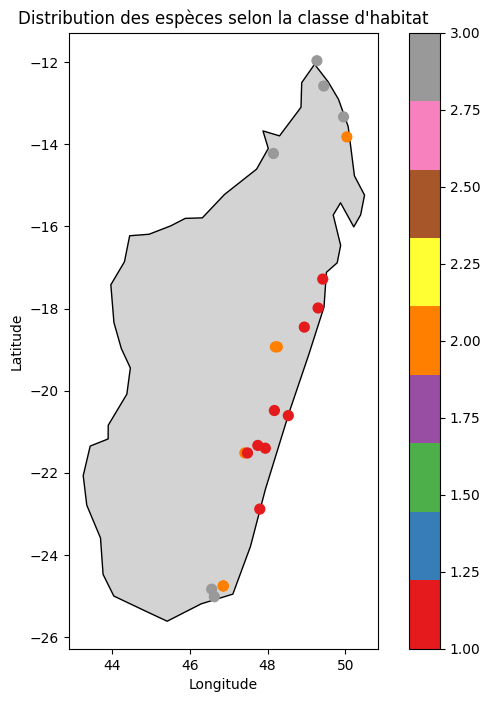

In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

# Fonction pour convertir les coordonnées en degrés décimaux
def dms_to_dd(coord):
    parts = re.split('[°′″ ]+', coord.strip())
    parts = [p for p in parts if p != '']
    if len(parts) >= 2:
        degrees = float(parts[0])
        minutes = float(parts[1])
        seconds = float(parts[2]) if len(parts) > 2 else 0
        dd = degrees + minutes / 60 + seconds / 3600
        if 'S' in coord or 'W' in coord:
            dd = -dd
        return dd
    else:
        return None

data = {
    'Species': [
        'C. tetragona', 'C. dubardii', 'C. heimii', 'C. farafanganensis',
        'C. ambodirianaensis', 'C. dolichophylla', 'C. richardii', 'C. abbayesii',
        'C. millotii', 'C. leroyi', 'C. andrambovatensis', 'C. resinosa',
        'C. vianneyi', 'C. arenesiana', 'C. bertrandii', 'C. perrieri',
        'C. pervilleana', 'C. tsirananae', 'C. lancifolia', 'C. homollei',
        'C. kianjavatensis'
    ],
    'Latitude': [
        '14°13′30″ S', '13°20′ S', '12°35′ S', '22°53′ S',
        '18°27′08″ S', '20°29′ S', '17°17′ S', '24°45′15″ S',
        '21°31′ S', '21°20′ S', '21°24′3″ S', '20°36′26.6″ S',
        '18°56′ S', '18°56′ S', '25°01′ S', '24°50′ S',
        '13°49′17″ S', '11°58′ S', '21°31′ S', '17°59′13″ S',
        '24°45′15″ S'
    ],
    'Longitude': [
        '48°09′ E', '49°57′ E', '49°26′30″ E', '47°48′ E',
        '48°56′36″ E', '48°10′30″ E', '49°25′ E', '46°51′45″ E',
        '47°25′ E', '47°45′ E', '47°56′32″ E', '48°31′56.5″ E',
        '48°15′ E', '48°12′ E', '46°38′ E', '46°33′55″ E',
        '50°02′04″ E', '49°16′ E', '47°29′ E', '49°17′48″ E',
        '46°51′45″ E'
    ],
    'Habitat class': [
        3, 3, 3, 1,
        1, 1, 1, 2,
        2, 1, 1, 1,
        2, 2, 3, 3,
        2, 3, 1, 1,
        2
    ]
}


# Convertir en DataFrame
df = pd.DataFrame(data)

# Convertir les coordonnées
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)

# Créer GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])],
    crs="EPSG:4326"
)

# Charger un fond de carte de Madagascar (exemple avec un fond mondial simplifié)
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']

# Tracer
fig, ax = plt.subplots(figsize=(8, 8))
madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(
    ax=ax,
    column='Habitat class',
    cmap='Set1',
    legend=True,
    markersize=50
)

plt.title('Distribution des espèces selon la classe d\'habitat')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\2999218276.py:33: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


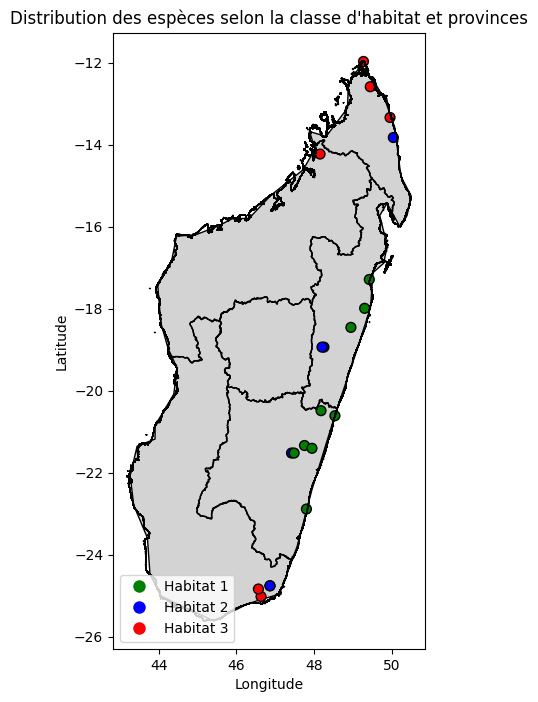

In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

def parse_dms(coord):
    pattern = r'(\d+)°(\d+)?′?(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    if not match:
        return None
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    dd = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        dd = -dd
    return dd

# Tes données (reprendre la liste complète que nous avons faite plus tôt)
# ...

# Conversion des coordonnées
df = pd.DataFrame(data)
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)
df = df.dropna(subset=['lat_dd', 'lon_dd'])

gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])], crs="EPSG:4326")

# Charger Madagascar
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']

# Charger limites des provinces (exemple: fichier shapefile ou geojson que tu as)
# Remplace par le chemin réel
provinces = gpd.read_file(r"./gadm41_MDG_1.shx")

# Tracer
fig, ax = plt.subplots(figsize=(8, 8))

madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
provinces.boundary.plot(ax=ax, color='black', linewidth=1)

# Colorer les points avec un mapping de couleur fixe
color_map = {1: 'green', 2: 'blue', 3: 'red'}
gdf.plot(
    ax=ax,
    color=gdf['Habitat class'].map(color_map),
    markersize=50,
    edgecolor='black'
)

# Légende manuelle
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Habitat 1', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 2', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 3', markerfacecolor='red', markersize=10),
]
ax.legend(handles=legend_elements, loc='lower left')

plt.title("Distribution des espèces selon la classe d'habitat et provinces")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Empty DataFrame
Columns: [Species, Latitude, Longitude]
Index: []


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\946588502.py:40: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


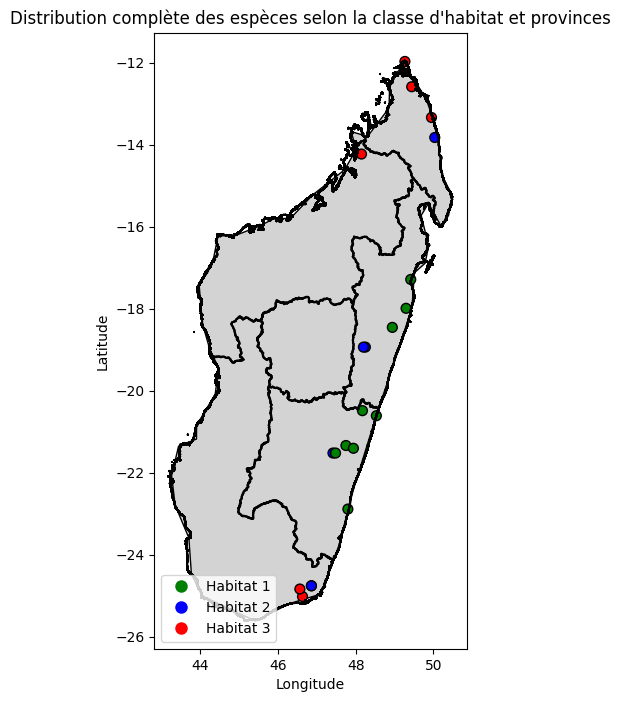

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

def parse_dms(coord):
    if pd.isnull(coord):
        return None
    pattern = r'(\d+)°\s*(\d+)?′?\s*(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    if not match:
        print(f"⚠️ Coordonnée non reconnue : {coord}")
        return None
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    dd = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        dd = -dd
    return dd

# Ton DataFrame complet avec toutes les espèces et coordonnées
# Remplace ici par ta liste complète (je peux la générer si tu veux)

# Convertir les coordonnées
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)

# Montrer les lignes où ça a échoué
print(df[df['lat_dd'].isnull() | df['lon_dd'].isnull()][['Species', 'Latitude', 'Longitude']])

# Créer le GeoDataFrame
gdf = gpd.GeoDataFrame(df.dropna(subset=['lat_dd', 'lon_dd']),
                        geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])],
                        crs="EPSG:4326")

# Charger fond de carte et provinces
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']
provinces = gpd.read_file("gadm41_MDG_1.shp")

# Tracer
fig, ax = plt.subplots(figsize=(8,8))
madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
provinces.boundary.plot(ax=ax, color='black')

color_map = {1: 'green', 2: 'blue', 3: 'red'}
gdf.plot(ax=ax, color=gdf['Habitat class'].map(color_map), markersize=50, edgecolor='black')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Habitat 1', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 2', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 3', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements, loc='lower left')

plt.title("Distribution complète des espèces selon la classe d'habitat et provinces")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


KeyError: 'nb_mois_secs'

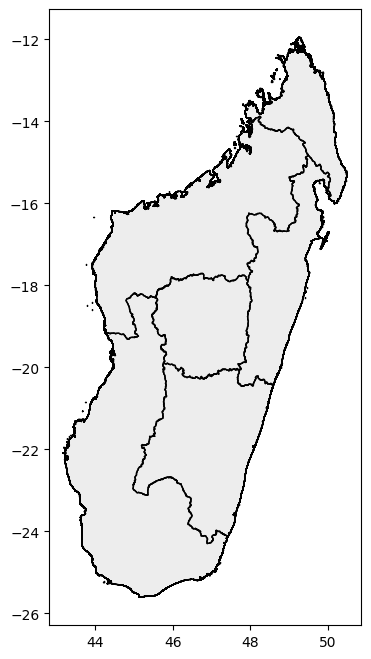

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

# gdf = GeoDataFrame contenant les colonnes geometry et nb_mois_secs
fig, ax = plt.subplots(figsize=(8, 8))

# Fond de carte
provinces = gpd.read_file("gadm41_MDG_1.shp")
provinces.boundary.plot(ax=ax, color="black", linewidth=1)
provinces.plot(ax=ax, color="lightgrey", alpha=0.4)

# Affichage des points avec nb_mois_secs
gdf.plot(
    ax=ax,
    column='nb_mois_secs',
    cmap='OrRd',  # ou autre colormap
    legend=True,
    markersize=50
)

plt.title("Nombre de mois de sécheresse (selon Gaussen)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
